# Anomaly Detection — Isolation Forest & DBSCAN
This notebook trains and evaluates two unsupervised anomaly detection models — Isolation Forest and DBSCAN — on the NSL-KDD network intrusion dataset.

## 1. Data Loading & Preprocessing
Load raw data, encode categorical features, and split into features and labels.

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from src.preprocessing import load_data
from src.preprocessing import encode_features
from src.preprocessing import split_features

In [3]:
train_data = load_data("../data/raw/KDDTrain+.txt")
test_data  = load_data("../data/raw/KDDTest+.txt")
train_data = encode_features(train_data)
test_data  = encode_features(test_data)

X_train, y_train = split_features(train_data)
X_test,  y_test  = split_features(test_data)

## 2. Feature Scaling
Standardize features using StandardScaler to ensure equal contribution across dimensions.

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(X_train)
x_test  = scaler.transform(X_test)

## 3. Isolation Forest
### 3.1 Training
Train Isolation Forest with contamination=0.5 to account for high attack ratio in NSL-KDD.

In [5]:
from src.isolation_forest_model import train_isolation_forest

model = train_isolation_forest(x_train)

In [6]:
from src.isolation_forest_model import detect_anomalies

predictions = detect_anomalies(model,x_test)

In [7]:
import numpy as np

np.unique(predictions, return_counts = True)

(array([-1,  1]), array([12892,  9652]))

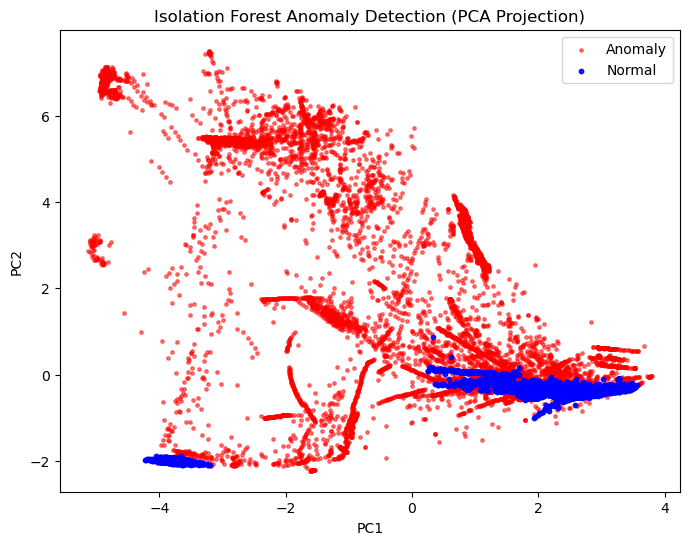

In [12]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

# Use model.predict() predictions (-1=anomaly, 1=normal)
normal  = x_test_pca[predictions == 1]
anomaly = x_test_pca[predictions == -1]

plt.figure(figsize=(8,6))
plt.scatter(anomaly[:,0], anomaly[:,1], s=6,  color="red",  label="Anomaly", alpha=0.5)
plt.scatter(normal[:,0],  normal[:,1],  s=10, color="blue", label="Normal",  alpha=0.9, zorder=5)

plt.title("Isolation Forest Anomaly Detection (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.savefig("../results/isolation_forest_pca.png", bbox_inches='tight')
plt.show()

### 3.2 Evaluation
Evaluate using confusion matrix and classification report.

In [13]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

attack_test = (y_test != "normal").astype(int)

pred = (predictions == -1).astype(int)

cm = confusion_matrix(attack_test, pred)
print(cm)

print(classification_report(attack_test, pred))

[[ 7147  2564]
 [ 2505 10328]]
              precision    recall  f1-score   support

           0       0.74      0.74      0.74      9711
           1       0.80      0.80      0.80     12833

    accuracy                           0.78     22544
   macro avg       0.77      0.77      0.77     22544
weighted avg       0.77      0.78      0.78     22544



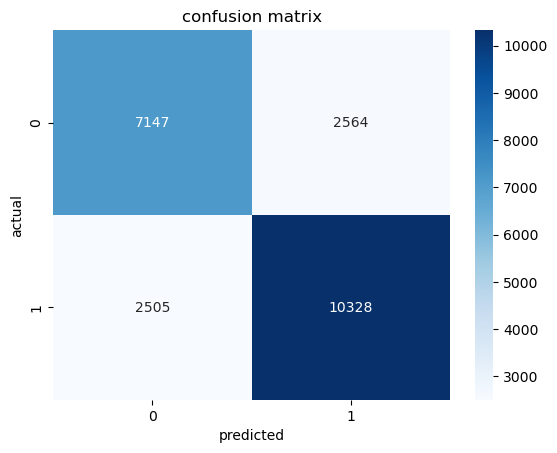

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot = True, fmt = 'd', cmap = "Blues")
plt.title("confusion matrix")
plt.xlabel("predicted")
plt.ylabel("actual")

plt.show()

In [15]:
import joblib

joblib.dump(model, "../results/isolation_forest_model.pkl")

['../results/isolation_forest_model.pkl']

In [16]:
# DBSCAN performs poorly on the NSL-KDD dataset due to the high
# dimensionality of the feature space. Density-based clustering
# methods rely on meaningful distance metrics, which degrade in
# high-dimensional environments. As a result, most data points are
# assigned to clusters and very few are labeled as noise (anomalies).

In [17]:
# Isolation Forest performs significantly better than DBSCAN on the NSL-KDD dataset
# because tree-based isolation methods handle high-dimensional data more effectively
# than density-based clustering algorithms.

### 3.3 Anomaly Score Distribution
Visualize the separation between normal and anomaly score distributions using a custom percentile-based threshold.

Best percentile: 30
Threshold:       0.2767
Best F1:         0.5111

Class distribution:
anomaly
1    15682
0     6862
Name: count, dtype: int64


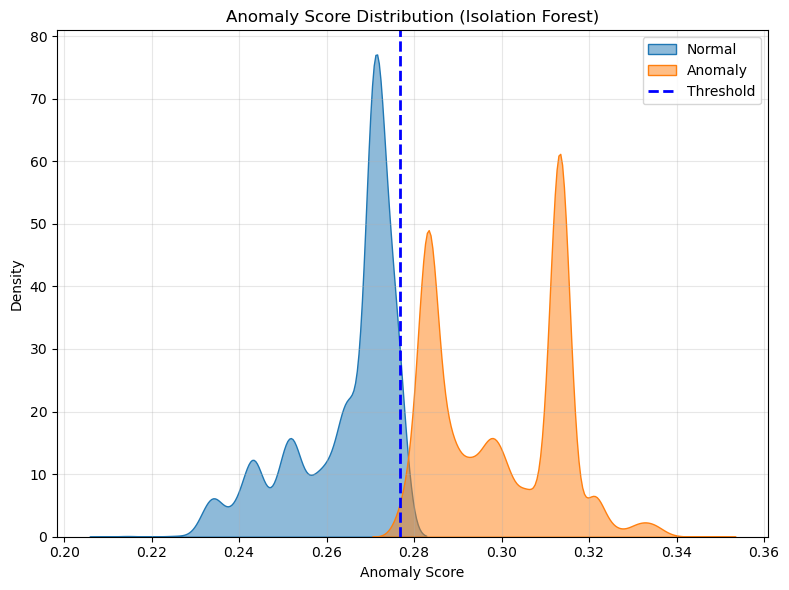

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score

X_test_np = X_test.values

# Scores
scores = model.decision_function(X_test_np)
anomaly_score = -scores
test_data["anomaly_score"] = anomaly_score

true_labels = (test_data["label"] != "normal").astype(int)

# Find best threshold by F1 across percentiles
best_f1, best_p, best_threshold = 0, 0, 0

for p in range(30, 99):
    t = np.percentile(anomaly_score, p)
    pred = (anomaly_score > t).astype(int)
    f1 = f1_score(true_labels, pred)
    if f1 > best_f1:
        best_f1, best_p, best_threshold = f1, p, t

print(f"Best percentile: {best_p}")
print(f"Threshold:       {best_threshold:.4f}")
print(f"Best F1:         {best_f1:.4f}")

threshold = best_threshold
test_data["anomaly"] = (anomaly_score > threshold).astype(int)

print("\nClass distribution:")
print(test_data["anomaly"].value_counts())

# Split scores by predicted class
normal_scores  = anomaly_score[test_data["anomaly"] == 0]
anomaly_scores = anomaly_score[test_data["anomaly"] == 1]

# Plot
plt.figure(figsize=(8, 6))

if len(normal_scores) > 1:
    sns.kdeplot(normal_scores, label="Normal", fill=True, alpha=0.5)

if len(anomaly_scores) > 1:
    sns.kdeplot(anomaly_scores, label="Anomaly", fill=True, alpha=0.5)

plt.axvline(threshold, linestyle="--", color="blue", linewidth=2, label="Threshold")

plt.title("Anomaly Score Distribution (Isolation Forest)")
plt.xlabel("Anomaly Score")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../results/anomaly_score_density.png", dpi=300)
plt.show()

In [19]:
# Isolation Forest shows partial separation between normal and attack traffic, but overlap in anomaly score distributions leads to missed detections.

In [20]:
percentiles = [90, 70, 50, 40, 30]

for p in percentiles:
    threshold = np.percentile(anomaly_score, p)
    pred = (anomaly_score > threshold).astype(int)

    detected = np.sum((pred == 1) & (test_data["label"] != "normal"))
    total = np.sum(test_data["label"] != "normal")

    print(f"{p}% → Detection Rate: {detected/total:.2f}")

90% → Detection Rate: 0.04
70% → Detection Rate: 0.08
50% → Detection Rate: 0.27
40% → Detection Rate: 0.37
30% → Detection Rate: 0.57


### 3.4 PCA Visualization
Project test data to 2D using PCA to visualize detected anomalies spatially.

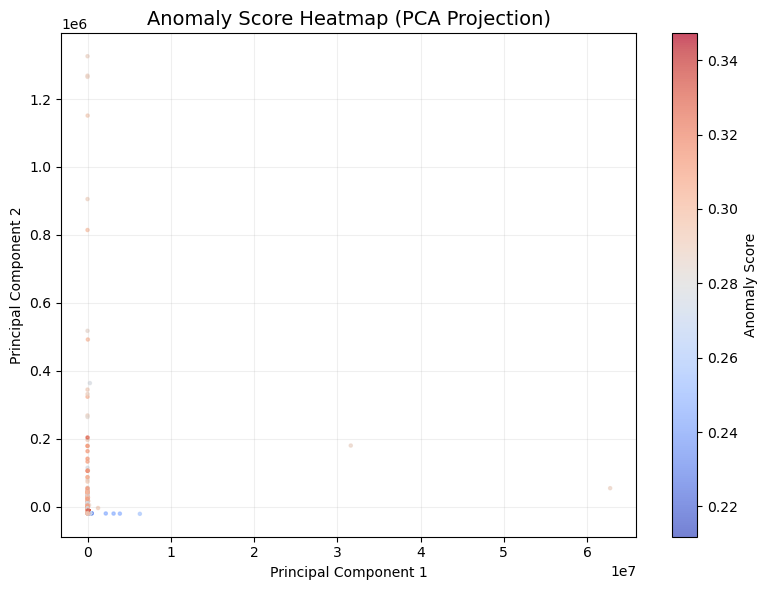

In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

x_train_pca = pca.fit_transform(X_train)
x_test_pca = pca.transform(X_test)



plt.figure(figsize=(8,6))

scatter = plt.scatter(
    x_test_pca[:,0],
    x_test_pca[:,1],
    c=test_data["anomaly_score"],
    cmap="coolwarm",
    s=5,
    alpha=0.7
)

cbar = plt.colorbar(scatter)
cbar.set_label("Anomaly Score")

plt.title("Anomaly Score Heatmap (PCA Projection)", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("../results/anomaly_heatmap.png", dpi=300)
plt.show()

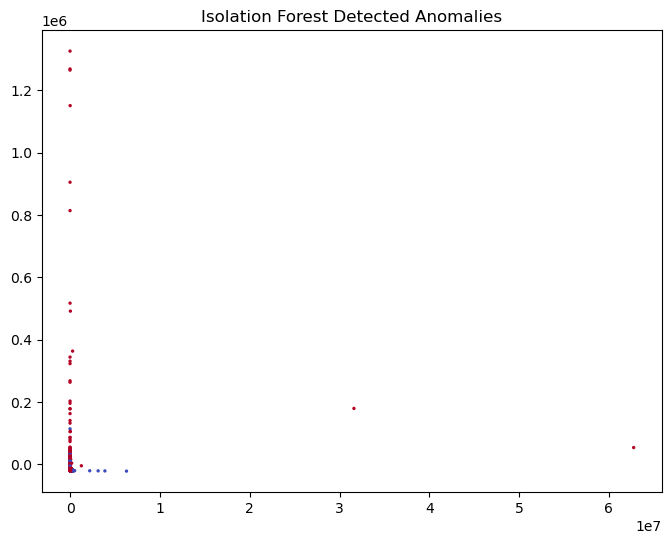

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(
    x_test_pca[:,0],
    x_test_pca[:,1],
    c=test_data["anomaly"],
    cmap="coolwarm",
    s=2
)

plt.title("Isolation Forest Detected Anomalies")

plt.show()

In [23]:
test_data.sort_values("anomaly_score", ascending=False).head(10)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,anomaly_score,anomaly
5360,0,1,22,4,54540,8314,0,0,0,3,...,0.01,0.00,0.0,0.00,0.00,0.04,0.04,back,0.347221,1
20734,988,1,55,9,1773,32209,0,0,0,4,...,0.03,0.00,0.0,0.33,0.77,0.02,0.01,rootkit,0.346864,1
11765,1776,1,55,9,3061,54942,0,0,0,15,...,0.44,0.11,1.0,0.00,0.00,0.00,0.00,multihop,0.345779,1
13011,0,1,22,4,16384,8314,0,0,0,2,...,0.01,0.00,0.0,0.00,0.00,0.02,0.02,back,0.340586,1
4352,135,1,55,9,353,5769,0,0,0,4,...,0.03,0.00,0.0,0.48,0.86,0.02,0.01,ps,0.340133,1
686,895,1,22,4,57184,1,0,0,0,0,...,0.00,0.00,0.0,0.03,0.03,0.65,0.65,apache2,0.339864,1
15487,0,1,22,9,54540,8314,0,0,0,2,...,0.00,0.00,0.0,0.01,0.01,0.06,0.06,back,0.339596,1
4500,75,1,55,9,277,1087,0,0,0,2,...,0.04,0.01,0.0,0.73,0.99,0.00,0.00,loadmodule,0.339420,1
15320,0,1,22,9,54540,8314,0,0,0,2,...,0.00,0.00,0.0,0.01,0.01,0.06,0.06,back,0.338504,1
12525,314,1,55,9,2602,3167,0,0,0,1,...,0.00,0.50,0.8,0.00,0.00,0.00,0.00,xterm,0.338227,1


In [24]:
test_data["label"].value_counts().head(10)

label
normal          9711
neptune         4657
guess_passwd    1231
mscan            996
warezmaster      944
apache2          737
satan            735
processtable     685
smurf            665
back             359
Name: count, dtype: int64

### 3.5 Feature Analysis
Identify which features differ most between normal and anomalous traffic.

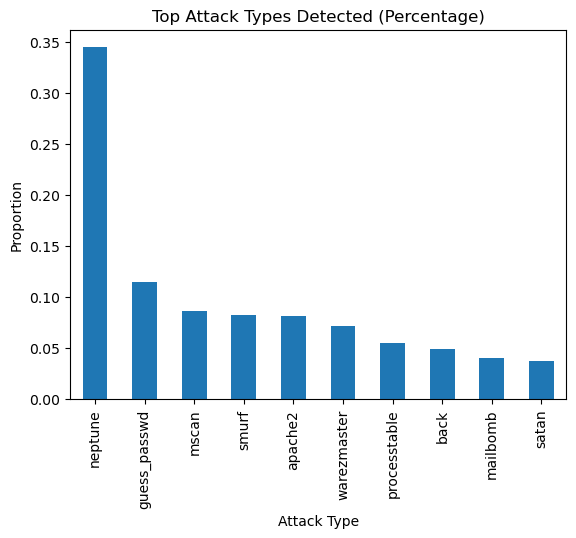

In [25]:
detected_attacks = test_data[
    (test_data["anomaly"] == 1) & (test_data["label"] != "normal")
]["label"].value_counts(normalize=True).head(10)

detected_attacks.plot(kind="bar")

plt.title("Top Attack Types Detected (Percentage)")
plt.xlabel("Attack Type")
plt.ylabel("Proportion")

plt.savefig("../results/detected_attacks.png", bbox_inches='tight')
plt.show()

In [26]:
false_positives = test_data[
    (test_data["anomaly"] == 1) & (test_data["label"] == "normal")
]
print("False positive rate:",
      len(false_positives) / len(test_data[test_data["label"] == "normal"]))

False positive rate: 0.8644835753269489


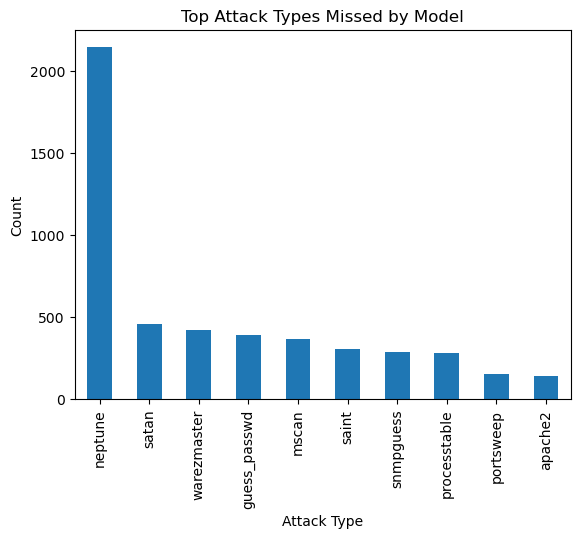

In [27]:
missed_attacks = test_data[
    (test_data["anomaly"] == 0) & (test_data["label"] != "normal")
]["label"].value_counts().head(10)

if len(missed_attacks) == 0:
    print("No missed attacks found")
else:
    missed_attacks.plot(kind="bar")
    plt.title("Top Attack Types Missed by Model")
    plt.xlabel("Attack Type")
    plt.ylabel("Count")
    plt.show()

In [28]:
anomalies = test_data[test_data['anomaly'] == 1]
anomalies['label'].value_counts().head(10)

label
normal          8395
neptune         2512
guess_passwd     839
mscan            629
smurf            601
apache2          596
warezmaster      523
processtable     402
back             359
mailbomb         293
Name: count, dtype: int64

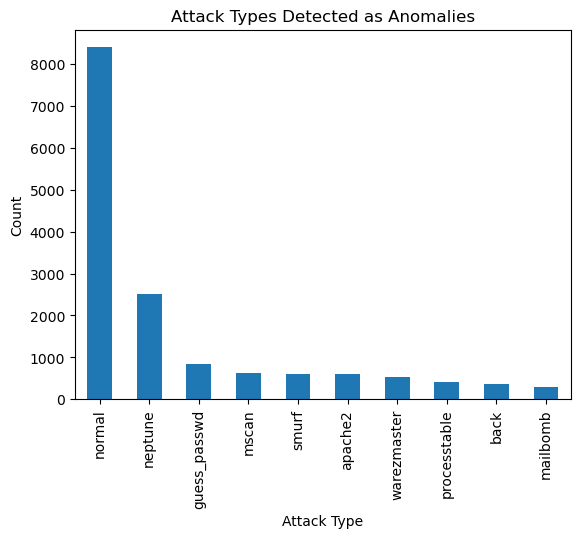

In [29]:
anomalies['label'].value_counts().head(10).plot(kind='bar')

plt.title("Attack Types Detected as Anomalies")
plt.xlabel("Attack Type")
plt.ylabel("Count")

plt.show()

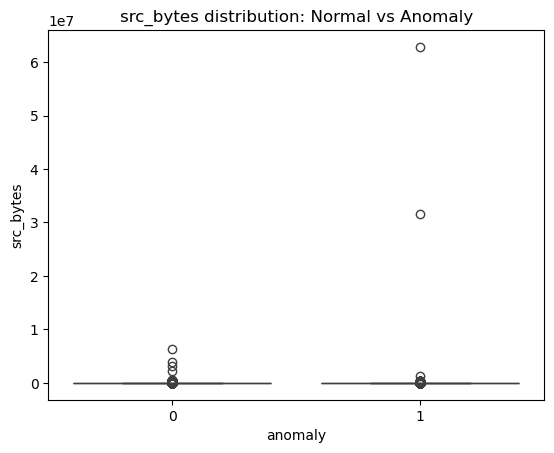

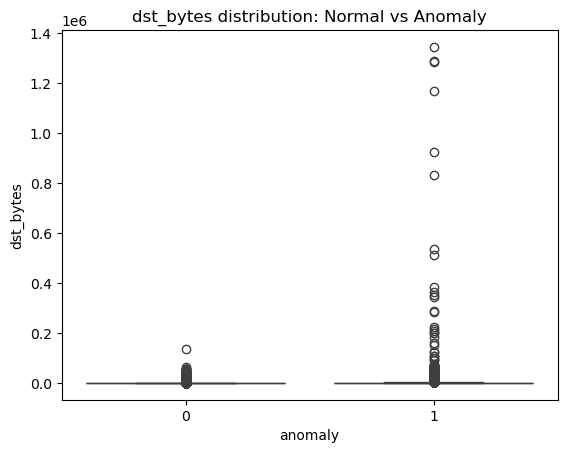

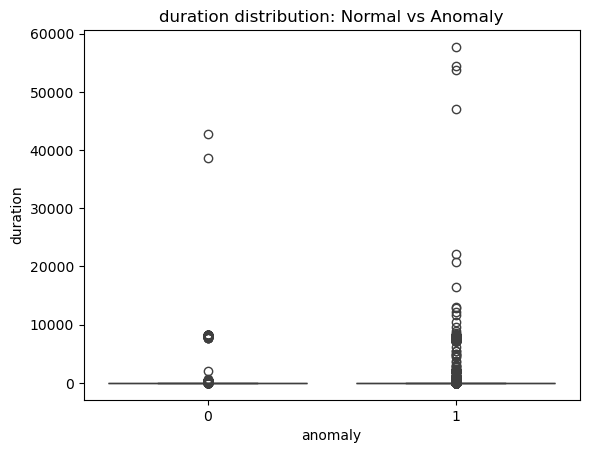

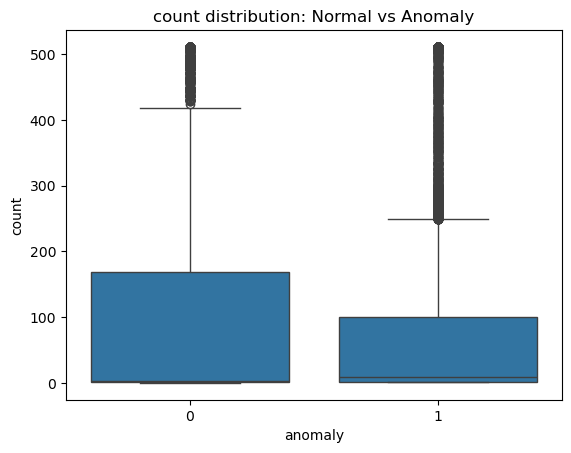

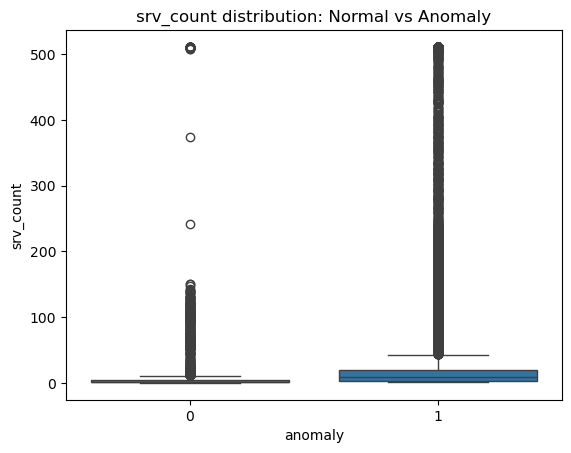

In [30]:
import seaborn as sns

features = ["src_bytes", "dst_bytes", "duration", "count", "srv_count"]

for feature in features:
    sns.boxplot(x=test_data["anomaly"], y=test_data[feature])
    plt.title(f"{feature} distribution: Normal vs Anomaly")
    plt.show()

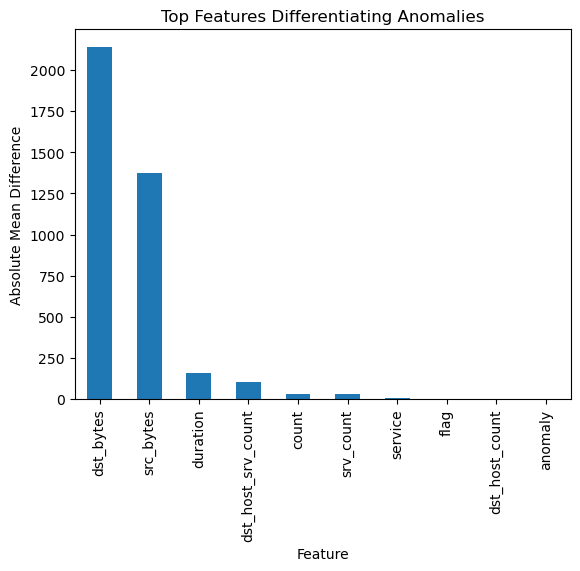

In [31]:
if test_data["anomaly"].nunique() < 2:
    print("Cannot compute feature differences (only one class present)")
else:
    numeric_data = test_data.select_dtypes(include=["int64", "float64"])

    normal = numeric_data[test_data["anomaly"] == 0]
    anomaly = numeric_data[test_data["anomaly"] == 1]

    diff = (anomaly.mean() - normal.mean()).abs().sort_values(ascending=False)
    diff.head(10).plot(kind='bar')
    plt.title("Top Features Differentiating Anomalies")
    plt.ylabel("Absolute Mean Difference")
    plt.xlabel("Feature")
    plt.show()

In [32]:
test_data.sort_values("anomaly_score", ascending=False).head(10)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,anomaly_score,anomaly
5360,0,1,22,4,54540,8314,0,0,0,3,...,0.01,0.00,0.0,0.00,0.00,0.04,0.04,back,0.347221,1
20734,988,1,55,9,1773,32209,0,0,0,4,...,0.03,0.00,0.0,0.33,0.77,0.02,0.01,rootkit,0.346864,1
11765,1776,1,55,9,3061,54942,0,0,0,15,...,0.44,0.11,1.0,0.00,0.00,0.00,0.00,multihop,0.345779,1
13011,0,1,22,4,16384,8314,0,0,0,2,...,0.01,0.00,0.0,0.00,0.00,0.02,0.02,back,0.340586,1
4352,135,1,55,9,353,5769,0,0,0,4,...,0.03,0.00,0.0,0.48,0.86,0.02,0.01,ps,0.340133,1
686,895,1,22,4,57184,1,0,0,0,0,...,0.00,0.00,0.0,0.03,0.03,0.65,0.65,apache2,0.339864,1
15487,0,1,22,9,54540,8314,0,0,0,2,...,0.00,0.00,0.0,0.01,0.01,0.06,0.06,back,0.339596,1
4500,75,1,55,9,277,1087,0,0,0,2,...,0.04,0.01,0.0,0.73,0.99,0.00,0.00,loadmodule,0.339420,1
15320,0,1,22,9,54540,8314,0,0,0,2,...,0.00,0.00,0.0,0.01,0.01,0.06,0.06,back,0.338504,1
12525,314,1,55,9,2602,3167,0,0,0,1,...,0.00,0.50,0.8,0.00,0.00,0.00,0.00,xterm,0.338227,1


In [33]:
print("Total attacks:", sum(test_data["label"] != "normal"))
print("Detected attacks:", sum((test_data["anomaly"] == 1) & (test_data["label"] != "normal")))
print("Missed attacks:", sum((test_data["anomaly"] == 0) & (test_data["label"] != "normal")))

Total attacks: 12833
Detected attacks: 7287
Missed attacks: 5546


In [34]:
print(np.percentile(anomaly_score, [10, 30, 50, 70, 90]))

[0.26423239 0.27669546 0.284876   0.30581921 0.31389769]


In [35]:
print(anomaly_score[test_data["label"] != "normal"].mean())
print(anomaly_score[test_data["label"] == "normal"].mean())

0.27990493670219924
0.3008422172273198


In [36]:
false_positives = np.sum(
    (test_data["anomaly"] == 1) & (test_data["label"] == "normal")
)

print("False Positives:", false_positives)

False Positives: 8395


In [37]:
print(test_data["anomaly"].value_counts())

anomaly
1    15682
0     6862
Name: count, dtype: int64


## 4. DBSCAN
### 4.1 Training & Evaluation
DBSCAN is a density-based clustering method. Points not belonging to any cluster (label = -1) are treated as anomalies.

In [38]:
from src.dbscan_model import train_dbscan

dbscan_labels = train_dbscan(x_train)

In [39]:
from sklearn.cluster import DBSCAN

dbscan_test = DBSCAN(eps=0.8, min_samples=10).fit(x_test)
dbscan_labels = dbscan_test.labels_

pred_dbscan = (dbscan_labels == -1).astype(int)

attack_test = (y_test != "normal").astype(int)

from sklearn.metrics import classification_report
print(classification_report(attack_test, pred_dbscan))

              precision    recall  f1-score   support

           0       0.44      0.93      0.60      9711
           1       0.67      0.11      0.18     12833

    accuracy                           0.46     22544
   macro avg       0.56      0.52      0.39     22544
weighted avg       0.57      0.46      0.36     22544



### 4.2 Limitations
DBSCAN struggles with high-dimensional data like NSL-KDD. Distance metrics lose meaning in high dimensions, leading to poor anomaly separation.

## 5. Save Metrics
Save evaluation metrics to JSON for use in the final model comparison.

In [43]:
import json
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# ── Isolation Forest (model.predict) ──────────────────────────────
if_pred = (predictions == -1).astype(int)

if_metrics = {
    "Precision":    round(precision_score(attack_test, if_pred), 2),
    "Recall":       round(recall_score(attack_test, if_pred), 2),
    "F1-Score":     round(f1_score(attack_test, if_pred), 2),
    "Accuracy":     round(accuracy_score(attack_test, if_pred), 2),
    "Key Behavior": "Tree-based isolation"
}

with open("../results/if_metrics.json", "w") as f:
    json.dump(if_metrics, f)

# ── DBSCAN ────────────────────────────────────────────────────────
dbscan_metrics = {
    "Precision":    round(precision_score(attack_test, pred_dbscan), 2),
    "Recall":       round(recall_score(attack_test, pred_dbscan), 2),
    "F1-Score":     round(f1_score(attack_test, pred_dbscan), 2),
    "Accuracy":     round(accuracy_score(attack_test, pred_dbscan), 2),
    "Key Behavior": "Density-based clustering"
}

with open("../results/dbscan_metrics.json", "w") as f:
    json.dump(dbscan_metrics, f)

print("IF metrics:    ", if_metrics)
print("DBSCAN metrics:", dbscan_metrics)

IF metrics:     {'Precision': 0.8, 'Recall': 0.8, 'F1-Score': 0.8, 'Accuracy': 0.78, 'Key Behavior': 'Tree-based isolation'}
DBSCAN metrics: {'Precision': 0.67, 'Recall': 0.11, 'F1-Score': 0.18, 'Accuracy': 0.46, 'Key Behavior': 'Density-based clustering'}
